# Week 4 - Univariate Analysis, part 2

**Dataset:** [Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) (Kaggle, `mirichoi0218/insurance`), one of the most popular datasets on Kaggle.
It has 1,338 US health-insurance policyholders, each with their age, sex, BMI, number of children, smoking status, region, and yearly medical **charges** billed by the insurer.

Contents:
1. Lesson - none
2. Weekly graph question (histogram vs. boxplot)
3. Homework - univariate analysis of the insurance dataset
4. Storytelling With Data - reproducing the slopegraph from Chapter 2

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', None)
# A small, consistent palette (colorblind-checked categorical order)
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
GRAY, DARK_GRAY = "#b5b4ae", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRAY,
    "axes.labelcolor": DARK_GRAY,
    "xtick.color": DARK_GRAY,
    "ytick.color": DARK_GRAY,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
})



# 2. Weekly graph question

A pharmacy keeps a record of the prices of the drugs it sells. An administrator wants to know **how much the more expensive drugs tend to cost, in the context of the other prices.**

### The original code

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: >

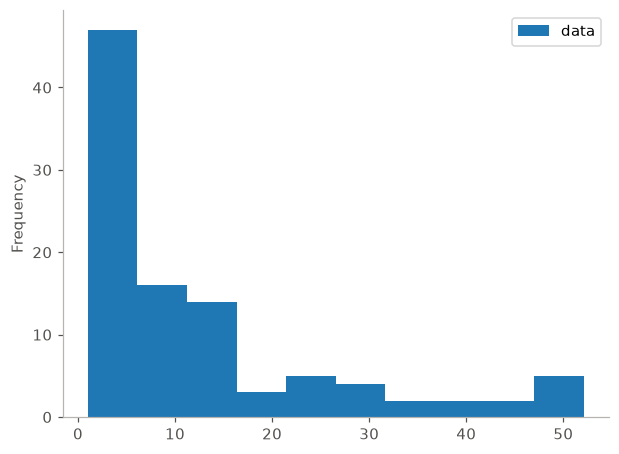

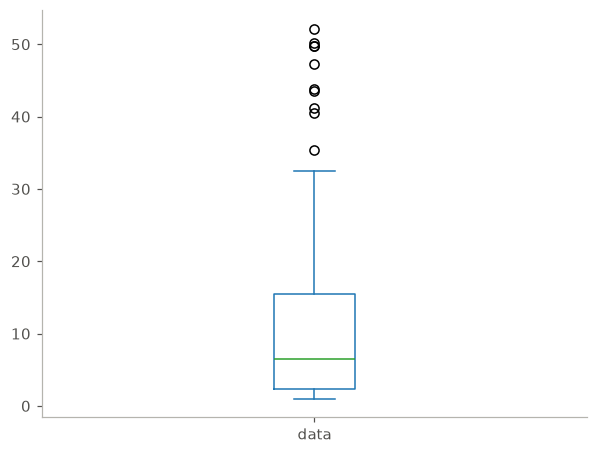

In [6]:
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()
df.plot.box()

In [7]:
# Numbers that both charts are trying to show
print(df["data"].describe(percentiles=[.25, .5, .75, .9]).round(2))
q1, q3 = df["data"].quantile([.25, .75])
upper_fence = q3 + 1.5 * (q3 - q1)
print(f"\nUpper whisker limit (Q3 + 1.5*IQR): {upper_fence:.2f}")
print("Drugs flagged as 'outliers' by the boxplot:", (df["data"] > upper_fence).sum())

count    100.00
mean      12.20
std       13.48
min        1.02
25%        2.28
50%        6.49
75%       15.46
90%       32.76
max       52.12
Name: data, dtype: float64

Upper whisker limit (Q3 + 1.5*IQR): 35.23
Drugs flagged as 'outliers' by the boxplot: 10


### Pros and cons

**Histogram**
- *Pros:* It shows the **shape** of the distribution. Most drugs are cheap: the first bar (about \$1 to \$6) holds roughly 40% of all drugs, and the counts fall off steadily after that, a long right tail typical of prices. You can see that expensive drugs are rare but not isolated; they form a continuous tail.
- *Cons:* It **does not answer the administrator's question directly.** There is no marker for "expensive" (such as the 75th percentile, about \$15.50), no median, and you have to estimate values by squinting at bin edges. With only 10 default bins, everything below about \$6 is squashed into one bar. The default formatting also hurts: the y-label says "Frequency" with no units, the legend just says "data", the x-axis has no "\$" or title, and there is no chart title.

**Boxplot**
- *Pros:* It is built for exactly this question. It shows the **median (about \$6.50), the quartiles, and the 75th percentile (about \$15.50)** at a glance, so "the expensive quarter of drugs costs more than about \$15" is easy to read off. The whisker and dots show how far the top end stretches (up to about \$52).
- *Cons:* It hides the shape. You can't tell that the data are heavily piled up at the low end, and you can't see how many drugs sit in each range. Worse, the 10 points above about \$35 are drawn as **"outliers"**, which suggests they are errors. They aren't: they are simply the most expensive drugs, which is the very group the administrator cares about. The default chart also has no units, no title, and an unhelpful "data" tick label.

### Which would I choose?

**The boxplot, with modifications.** The question is about where the expensive drugs sit relative to the rest, which is about percentiles, and the boxplot shows percentiles directly. To fix its weaknesses I would:

1. **Turn it horizontal** so the price axis reads left to right like a number line, and add a "\$" axis format and a title that states the takeaway.
2. **Overlay the individual drugs** as faint jittered dots (a strip plot), so the boxplot no longer hides the shape or the sample size.
3. **Highlight the top 25%** (everything above the 75th percentile) in an accent color and **label the key values** (median, 75th percentile, maximum) directly on the chart.
4. **Stop calling expensive drugs "outliers"**: draw them in the same accent color as the rest of the top quarter.

For comparison, I also made an improved histogram with narrower bins and the same highlight, since the two views complement each other.

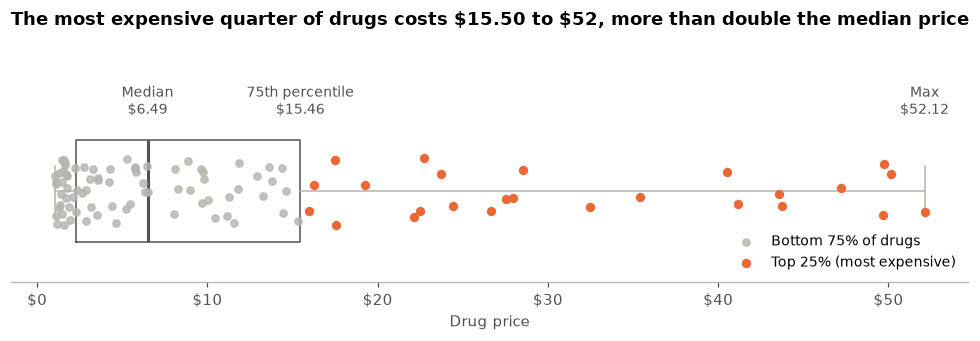

In [8]:
prices = df["data"]
median, p75, pmax = prices.median(), prices.quantile(.75), prices.max()
is_top = prices > p75

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.boxplot(prices, orientation="horizontal", widths=0.45, showfliers=False, whis=(0, 100),
           boxprops=dict(color=DARK_GRAY), medianprops=dict(color=DARK_GRAY, linewidth=2),
           whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY))
rng = np.random.default_rng(1)
jitter = 1 + rng.uniform(-0.15, 0.15, len(prices))
ax.scatter(prices[~is_top], jitter[~is_top], s=22, color=GRAY, alpha=.8, zorder=3, label="Bottom 75% of drugs")
ax.scatter(prices[is_top], jitter[is_top], s=26, color=ORANGE, zorder=3, label="Top 25% (most expensive)")

for x, label in [(median, f"Median\n${median:.2f}"), (p75, f"75th percentile\n${p75:.2f}"), (pmax, f"Max\n${pmax:.2f}")]:
    ax.annotate(label, (x, 1.32), ha="center", va="bottom", fontsize=9, color=DARK_GRAY)

ax.set_ylim(0.6, 1.65)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_xlabel("Drug price")
ax.set_title("The most expensive quarter of drugs costs \\$15.50 to \\$52, more than double the median price", pad=12)
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("graph_question_improved_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

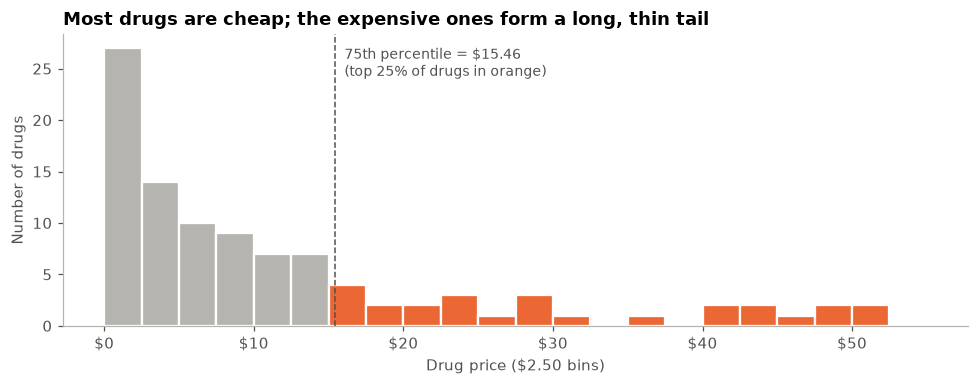

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.arange(0, 56, 2.5)
counts, edges, patches = ax.hist(prices, bins=bins, color=GRAY, edgecolor="white", linewidth=1.5)
for patch, left in zip(patches, edges[:-1]):
    if left >= p75 - 1e-9 or (left < p75 < left + 2.5):
        patch.set_facecolor(ORANGE)
ax.axvline(p75, color=DARK_GRAY, linestyle="--", linewidth=1)
ax.text(p75 + 0.6, counts.max() * 0.9, f"75th percentile = ${p75:.2f}\n(top 25% of drugs in orange)", fontsize=9, color=DARK_GRAY)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_xlabel("Drug price ($2.50 bins)")
ax.set_ylabel("Number of drugs")
ax.set_title("Most drugs are cheap; the expensive ones form a long, thin tail")
plt.tight_layout()
plt.savefig("graph_question_improved_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

**Final answer:** I would show the administrator the **modified boxplot**. It answers "how much do the expensive drugs cost?" in one glance (the top quarter costs more than about \$15.50 and runs up to about \$52), and the overlaid dots keep the honesty of the histogram by showing that most drugs cluster under \$10.

# 3. Homework - Medical Cost Personal Dataset (Kaggle)

The data was downloaded with `kagglehub.dataset_download("mirichoi0218/insurance")`; `insurance.csv` is saved next to this notebook.

| Column | Type | Meaning |
|---|---|---|
| `age` | numeric | age of the primary beneficiary (18-64) |
| `sex` | categorical | female / male |
| `bmi` | numeric | body-mass index (kg/m²) |
| `children` | discrete numeric | number of dependents covered |
| `smoker` | categorical | yes / no |
| `region` | categorical | US region: northeast, northwest, southeast, southwest |
| `charges` | numeric | individual medical costs billed by the insurer (\$/year) |

In [10]:
import os, shutil

# Download the dataset from Kaggle the first time (needs internet); afterwards the local copy is used
if not os.path.exists("insurance.csv"):
    import kagglehub   # pip install kagglehub
    path = kagglehub.dataset_download("mirichoi0218/insurance")
    shutil.copy(os.path.join(path, "insurance.csv"), "insurance.csv")

ins = pd.read_csv("insurance.csv")
ins.head()

c:\Users\romeo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [12]:
ins.describe(include='all').round(2)

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


In [13]:
print("Missing values per column:\n", ins.isna().sum(), sep="")
print("\nDuplicate rows:", ins.duplicated().sum())
ins[ins.duplicated(keep=False)]

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Data quality:** There are no missing values and the dtypes are correct (numbers are numbers, categories are strings). There is **one duplicated row** (a 19-year-old male, BMI 30.59, non-smoker, northwest). It could plausibly be two different people with identical attributes, but it's far more likely to be a data-entry duplicate, so I drop it. That leaves 1,337 rows.

In [14]:
ins = ins.drop_duplicates().reset_index(drop=True)
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]
ins.shape

(1337, 7)

## 3.1 Means, medians, and modes

In [15]:
summary = pd.DataFrame({
    "mean":   ins[numeric_cols].mean(),
    "median": ins[numeric_cols].median(),
    "mode":   ins[numeric_cols].mode().iloc[0],
    "min":    ins[numeric_cols].min(),
    "max":    ins[numeric_cols].max(),
    "std":    ins[numeric_cols].std(),
    "skew":   ins[numeric_cols].skew(),
}).round(2)
summary

,mean,median,mode,min,max,std,skew
age,39.22,39.00,18.00,18.00,64.00,14.04,0.05
bmi,30.66,30.40,32.30,15.96,53.13,6.10,0.28
children,1.10,1.00,0.00,0.00,5.00,1.21,0.94
charges,13279.12,9386.16,1121.87,1121.87,63770.43,12110.36,1.52


In [16]:
# Modes of the categorical columns
for col in categorical_cols:
    print(f"{col:7s} mode = {ins[col].mode()[0]!r:12s} ({ins[col].value_counts().iloc[0]} of {len(ins)})")

sex     mode = 'male'       (675 of 1337)
smoker  mode = 'no'         (1063 of 1337)
region  mode = 'southeast'  (364 of 1337)


- **age:** mean ≈ median (39.2 vs 39), so it's symmetric. The mode is **18**, an early hint of the spike at the youngest ages.
- **bmi:** mean (30.7) ≈ median (30.4), so it's nearly symmetric with a slight right skew. The average person here is at the clinical "obese" threshold (BMI ≥ 30).
- **children:** median 1, mode **0**, right-skewed.
- **charges:** the mean (\$13,279) is **42% higher than the median (\$9,386)**, a strong right skew (skew ≈ 1.5). The "mode" is meaningless here: charges is continuous and after dropping the duplicate every value is unique, so pandas simply returns the smallest value (\$1,122). For continuous data like this, the median is the better "typical" value.

## 3.2 Histograms of each numeric column

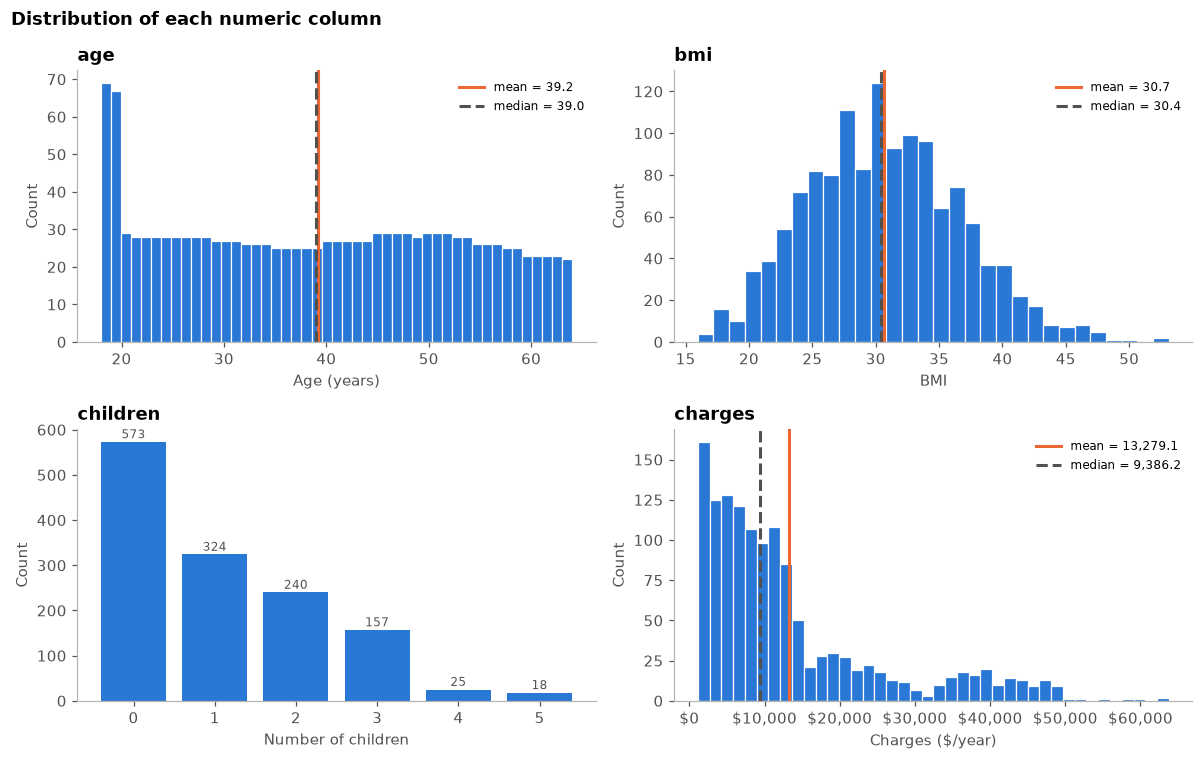

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
specs = [("age", 47, "Age (years)"), ("bmi", 30, "BMI"), ("charges", 40, "Charges ($/year)")]
for ax, (col, bins, label) in zip([axes[0, 0], axes[0, 1], axes[1, 1]], specs):
    ax.hist(ins[col], bins=bins, color=BLUE, edgecolor="white", linewidth=0.8)
    ax.axvline(ins[col].mean(), color=ORANGE, linewidth=2, label=f"mean = {ins[col].mean():,.1f}")
    ax.axvline(ins[col].median(), color=DARK_GRAY, linewidth=2, linestyle="--", label=f"median = {ins[col].median():,.1f}")
    ax.set_xlabel(label); ax.set_ylabel("Count"); ax.legend(frameon=False, fontsize=8)
    ax.set_title(col)

# children is discrete (0-5), so one bar per value is the honest histogram
ch = ins["children"].value_counts().sort_index()
axes[1, 0].bar(ch.index, ch.values, color=BLUE, width=0.8)
for x, y in ch.items():
    axes[1, 0].text(x, y + 8, y, ha="center", fontsize=8, color=DARK_GRAY)
axes[1, 0].set_xlabel("Number of children"); axes[1, 0].set_ylabel("Count"); axes[1, 0].set_title("children")

axes[1, 1].xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
fig.suptitle("Distribution of each numeric column", fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("hist_numeric_columns.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# The spike at the youngest ages in the age histogram
age_counts = ins["age"].value_counts().sort_index()
print("People aged 18:", age_counts[18], "| aged 19:", age_counts[19],
      "| typical count for any other age:", int(age_counts.drop([18, 19]).median()))

People aged 18: 69 | aged 19: 67 | typical count for any other age: 27


## 3.3 Histogram variants: KDE, violin, and swarm plots

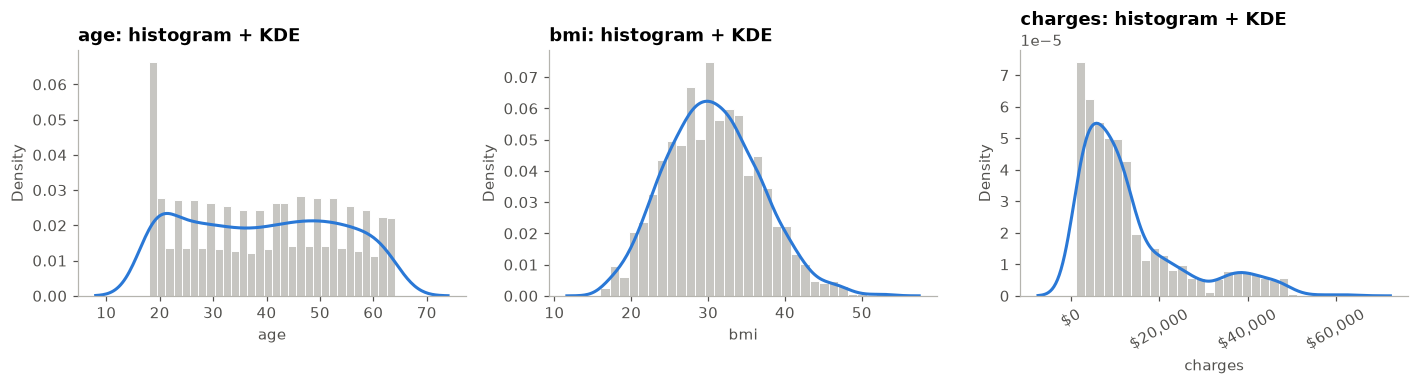

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ["age", "bmi", "charges"]):
    sns.histplot(ins[col], stat="density", bins=30, color=GRAY, edgecolor="white", ax=ax)
    sns.kdeplot(ins[col], color=BLUE, linewidth=2, ax=ax)
    ax.set_title(f"{col}: histogram + KDE")
axes[2].xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
axes[2].tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.savefig("kde_plots.png", dpi=150, bbox_inches="tight")
plt.show()

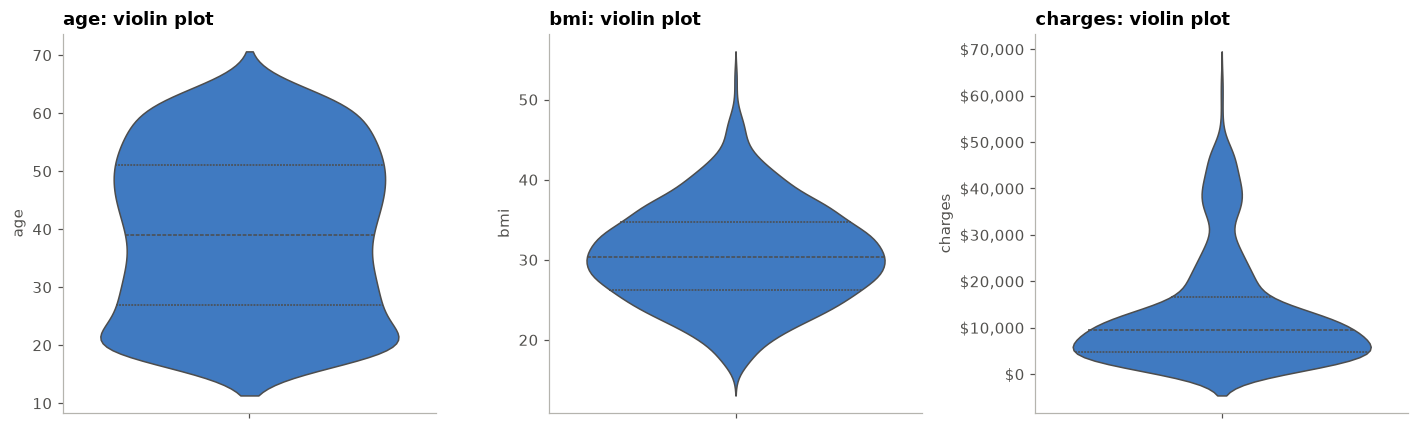

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["age", "bmi", "charges"]):
    sns.violinplot(y=ins[col], color=BLUE, inner="quartile", ax=ax, linewidth=1)
    ax.set_title(f"{col}: violin plot")
axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig("violin_plots.png", dpi=150, bbox_inches="tight")
plt.show()

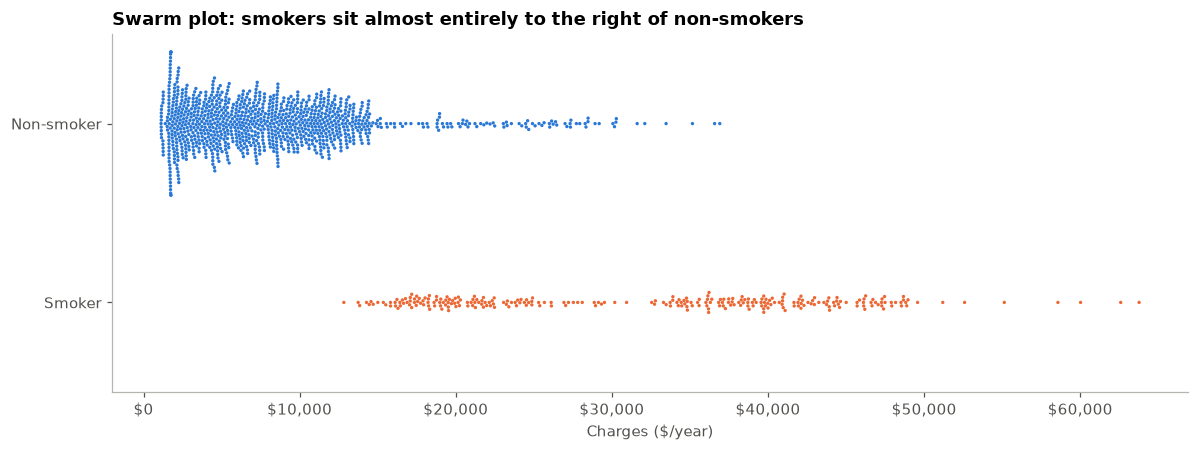

In [21]:
# Swarm plot of charges split by smoker status: every dot is one person
fig, ax = plt.subplots(figsize=(11, 4.2))
sns.swarmplot(data=ins, x="charges", y="smoker", hue="smoker", order=["no", "yes"],
              palette={"no": BLUE, "yes": ORANGE}, size=2.2, ax=ax, legend=False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_yticks([0, 1], ["Non-smoker", "Smoker"])
ax.set_ylabel(""); ax.set_xlabel("Charges ($/year)")
ax.set_title("Swarm plot: smokers sit almost entirely to the right of non-smokers")
plt.tight_layout()
plt.savefig("swarm_charges_by_smoker.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.4 Bar plots of each categorical column

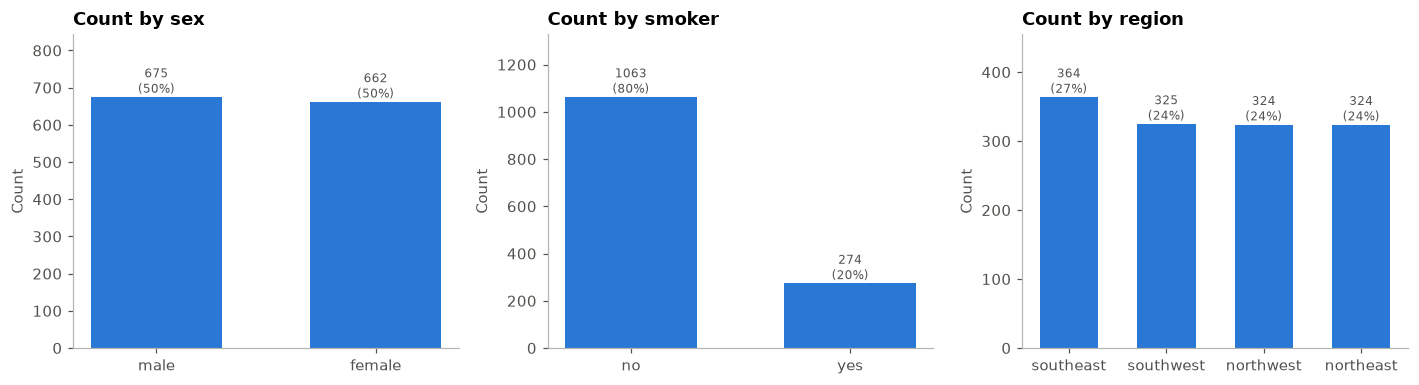

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, categorical_cols):
    counts = ins[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=BLUE, width=0.6)
    ax.bar_label(bars, labels=[f"{v}\n({v/len(ins):.0%})" for v in counts.values], fontsize=8, color=DARK_GRAY)
    ax.set_title(f"Count by {col}")
    ax.set_ylabel("Count")
    ax.set_ylim(0, counts.max() * 1.25)
plt.tight_layout()
plt.savefig("bar_categorical_counts.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.5 Grouped histograms

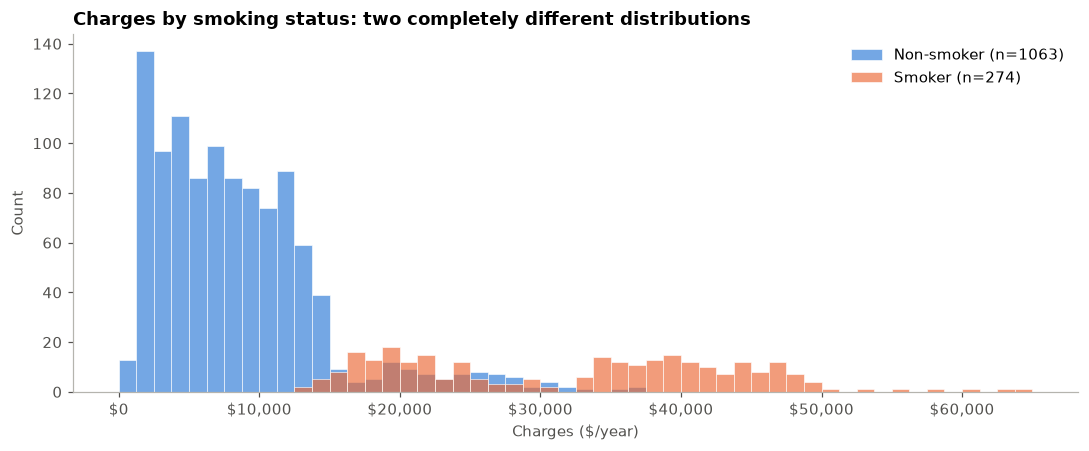

,count,mean,median,min,max
smoker,,,,,
no,1063,8441.0,7346.0,1122.0,36911.0
yes,274,32050.0,34456.0,12829.0,63770.0


In [23]:
fig, ax = plt.subplots(figsize=(10, 4.2))
bins = np.linspace(0, 65000, 53)
for grp, color, name in [("no", BLUE, "Non-smoker"), ("yes", ORANGE, "Smoker")]:
    ax.hist(ins.loc[ins.smoker == grp, "charges"], bins=bins, color=color, alpha=0.65,
            edgecolor="white", linewidth=0.6, label=f"{name} (n={(ins.smoker == grp).sum()})")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_xlabel("Charges ($/year)"); ax.set_ylabel("Count")
ax.set_title("Charges by smoking status: two completely different distributions")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("grouped_hist_charges_smoker.png", dpi=150, bbox_inches="tight")
plt.show()

ins.groupby("smoker")["charges"].agg(["count", "mean", "median", "min", "max"]).round(0)

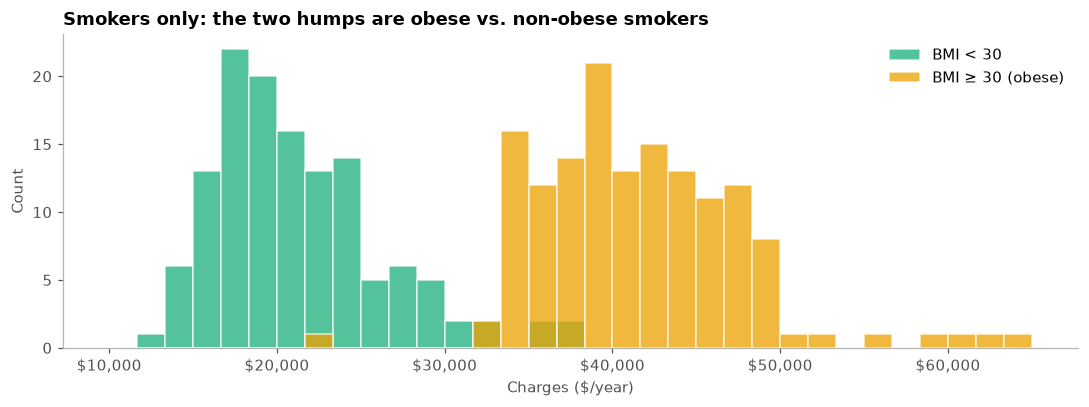

,count,median
bmi_group,,
BMI < 30,129,20167.0
BMI ≥ 30 (obese),145,40904.0


In [24]:
# Within smokers the distribution is bimodal. Splitting on the obesity line (BMI 30) explains it.
smokers = ins[ins.smoker == "yes"].copy()
smokers["bmi_group"] = np.where(smokers.bmi >= 30, "BMI ≥ 30 (obese)", "BMI < 30")

fig, ax = plt.subplots(figsize=(10, 3.8))
for grp, color in [("BMI < 30", AQUA), ("BMI ≥ 30 (obese)", YELLOW)]:
    ax.hist(smokers.loc[smokers.bmi_group == grp, "charges"], bins=np.linspace(10000, 65000, 34),
            color=color, alpha=0.75, edgecolor="white", label=grp)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_xlabel("Charges ($/year)"); ax.set_ylabel("Count")
ax.set_title("Smokers only: the two humps are obese vs. non-obese smokers")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("grouped_hist_smokers_bmi.png", dpi=150, bbox_inches="tight")
plt.show()

smokers.groupby("bmi_group")["charges"].agg(["count", "median"]).round(0)

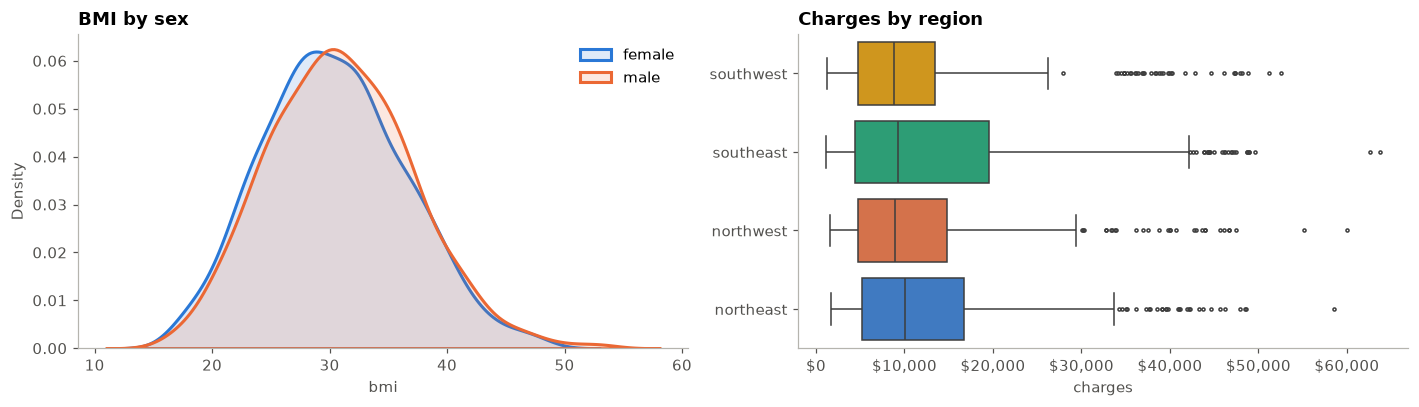

,bmi,charges
region,,
northeast,28.9,10057.7
northwest,28.9,8977.0
southeast,33.3,9294.1
southwest,30.3,8798.6


In [25]:
# BMI by sex and charges by region: small multiples sharing the same axes
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for grp, color in [("female", BLUE), ("male", ORANGE)]:
    sns.kdeplot(ins.loc[ins.sex == grp, "bmi"], color=color, linewidth=2, label=grp, ax=axes[0], fill=True, alpha=.15)
axes[0].set_title("BMI by sex"); axes[0].legend(frameon=False)

region_colors = dict(zip(["northeast", "northwest", "southeast", "southwest"], [BLUE, ORANGE, AQUA, YELLOW]))
sns.boxplot(data=ins, x="charges", y="region", hue="region", palette=region_colors, ax=axes[1],
            fliersize=2, linewidth=1, legend=False)
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
axes[1].set_title("Charges by region"); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("grouped_bmi_sex_charges_region.png", dpi=150, bbox_inches="tight")
plt.show()

ins.groupby("region")[["bmi", "charges"]].median().round(1)

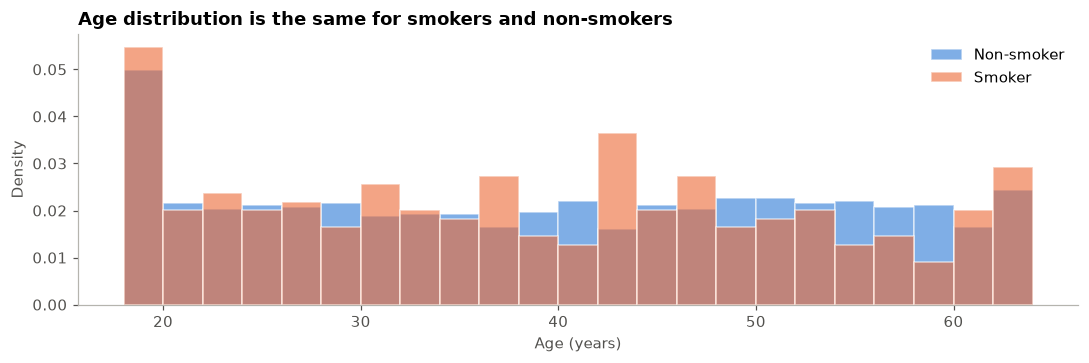

In [26]:
# Age by smoker status: does age explain the charges gap? (No: the age distributions are nearly identical)
fig, ax = plt.subplots(figsize=(10, 3.4))
bins = np.arange(18, 66, 2)
for grp, color, name in [("no", BLUE, "Non-smoker"), ("yes", ORANGE, "Smoker")]:
    ax.hist(ins.loc[ins.smoker == grp, "age"], bins=bins, density=True, color=color, alpha=0.6, edgecolor="white", label=name)
ax.set_xlabel("Age (years)"); ax.set_ylabel("Density")
ax.set_title("Age distribution is the same for smokers and non-smokers")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3.6 How bin size changes the histogram

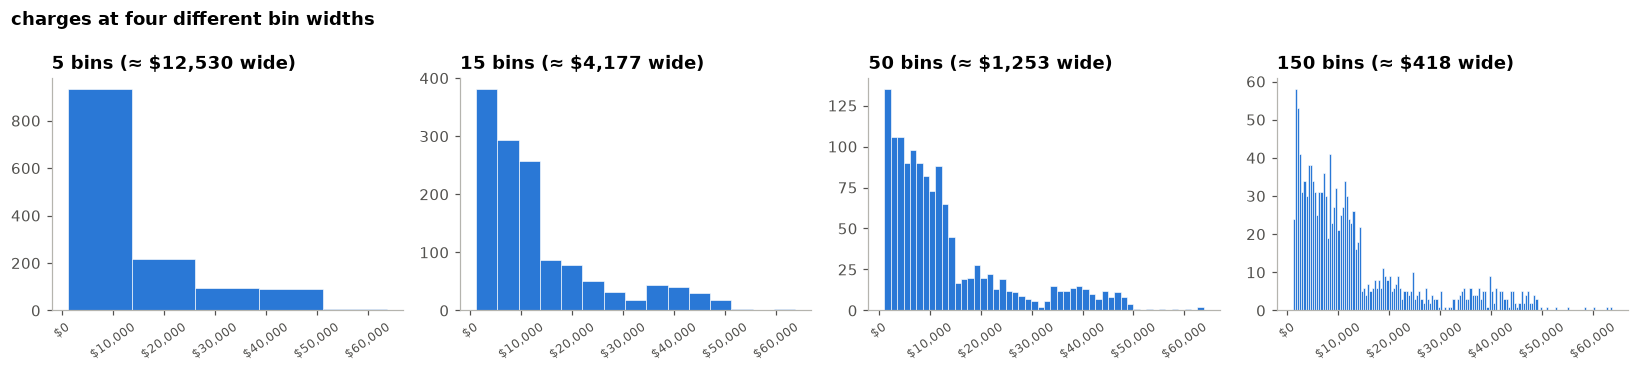

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=False)
for ax, nbins in zip(axes, [5, 15, 50, 150]):
    ax.hist(ins["charges"], bins=nbins, color=BLUE, edgecolor="white", linewidth=0.4)
    width = (ins.charges.max() - ins.charges.min()) / nbins
    ax.set_title(f"{nbins} bins (≈ ${width:,.0f} wide)")
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)
fig.suptitle("charges at four different bin widths", fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("bin_size_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

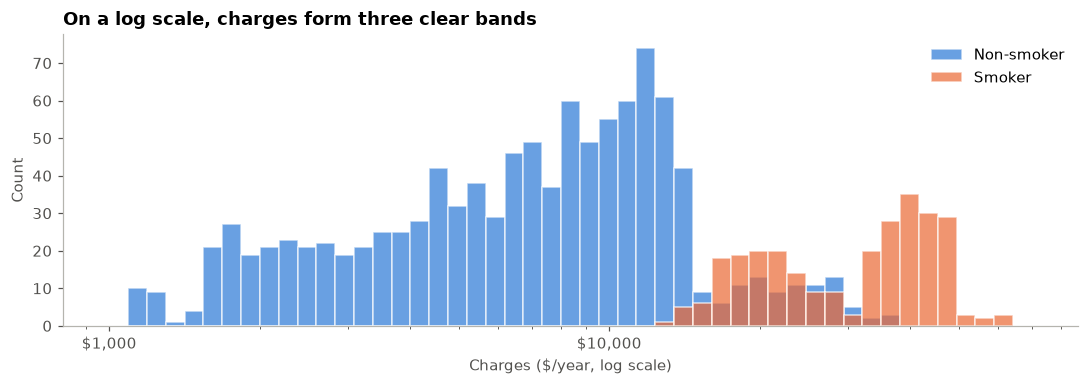

In [28]:
# Because charges are right-skewed, a log-scaled x-axis with log-spaced bins is often more informative
fig, ax = plt.subplots(figsize=(10, 3.6))
log_bins = np.logspace(np.log10(1000), np.log10(70000), 50)
for grp, color, name in [("no", BLUE, "Non-smoker"), ("yes", ORANGE, "Smoker")]:
    ax.hist(ins.loc[ins.smoker == grp, "charges"], bins=log_bins, color=color, alpha=0.7, edgecolor="white", label=name, stacked=False)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_xlabel("Charges ($/year, log scale)"); ax.set_ylabel("Count")
ax.set_title("On a log scale, charges form three clear bands")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("charges_log_scale.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.7 Outliers

In [29]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    return lo, hi, ((s < lo) | (s > hi)).sum()

rows = []
for col in ["age", "bmi", "children", "charges"]:
    lo, hi, n = iqr_outliers(ins[col])
    rows.append({"column": col, "lower fence": round(lo, 1), "upper fence": round(hi, 1), "n outliers (1.5*IQR)": n})
pd.DataFrame(rows)

,column,lower fence,upper fence,n outliers (1.5*IQR)
0,age,-9.0,87.0,0
1,bmi,13.7,47.3,9
2,children,-3.0,5.0,0
3,charges,-13120.7,34524.8,139


In [30]:
_, hi, _ = iqr_outliers(ins["charges"])
out = ins[ins.charges > hi]
print(f"{len(out)} charges above ${hi:,.0f}; smokers among them: {(out.smoker == 'yes').sum()} ({(out.smoker == 'yes').mean():.0%})")
_, hi_bmi, _ = iqr_outliers(ins["bmi"])
ins[ins.bmi > hi_bmi].sort_values("bmi")

139 charges above $34,525; smokers among them: 136 (98%)


,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801
401,47,male,47.52,1,no,southeast,8083.91980
859,37,female,47.60,2,yes,southwest,46113.51100
1087,52,male,47.74,1,no,southeast,9748.91060
286,46,female,48.07,2,no,northeast,9432.92530
116,58,male,49.06,0,no,southeast,11381.32540
846,23,male,50.38,1,no,southeast,2438.05520
1046,22,male,52.58,1,yes,southeast,44501.39820
1316,18,male,53.13,0,no,southeast,1163.46270


## 3.8 Conclusions

**Are the data what I expected? Are they usable?**
Yes, and yes. This is a clean, well-structured dataset: no missing values, correct data types, plausible ranges (ages 18-64, BMI 16-53, charges \$1,122-\$63,770), and only one duplicate row, which I removed. The categories are well balanced (sex is about 50/50 and the four regions each hold about 25%), so group comparisons are fair. The patterns match what you'd expect from real insurance data: costs are right-skewed, and smoking dominates them. One caveat: the dataset is widely believed to be partly **simulated** (based on the textbook *Machine Learning with R*), which explains how tidy it is. It is very usable for learning and analysis, but I wouldn't use it to set real insurance prices.

**Overall shape of each distribution**

| Column | Shape | Min | Max | Notes |
|---|---|---|---|---|
| `age` | **Roughly uniform** from 20 to 64, with a **spike at 18-19** | 18 | 64 | about 68 people at each of 18 and 19, vs. about 27 at every other age. Likely an artifact of how the data were sampled or generated |
| `bmi` | **Approximately normal**, slight right skew (skew 0.28) | 15.96 | 53.13 | mean ≈ median ≈ 30.5. The KDE looks bell-shaped |
| `children` | **Right-skewed**, discrete | 0 | 5 | 43% have no children; only 3% have 4 or 5 |
| `charges` | **Strongly right-skewed** (skew 1.5) and **multimodal** | \$1,122 | \$63,770 | mean \$13,279 vs. median \$9,386 |
| `sex`, `region` | about uniform across categories | | | |
| `smoker` | imbalanced: 20% yes, 80% no | | | |

**Are there outliers?**
- **charges:** 139 points lie above the 1.5×IQR fence (about \$34,500), and **136 of them (98%) are smokers**. They are **not errors**. They are a real, distinct sub-population (smokers, especially obese smokers), so they should be kept and analysed as a group, not deleted.
- **bmi:** 9 points above about 47.3 (BMI up to 53). These are extreme but physiologically possible (severe obesity), so I keep them.
- **age** and **children:** no outliers by the IQR rule.

**How does the distribution change across groups?**
- **Smoker vs. non-smoker** is the big story. Non-smokers have a median charge of about **\$7,350**; smokers have about **\$34,500**, nearly **5× higher**. The smoker distribution barely overlaps the bulk of the non-smoker one (the smoker minimum is about \$12,800).
- **Within smokers**, the histogram is **bimodal**, and splitting on BMI 30 explains it: non-obese smokers cluster around \$20,000 and obese smokers around \$40,000+.
- On a **log scale**, all charges fall into **three bands**: non-smokers (low), non-obese smokers (middle), and obese smokers (high). The long right tail of the overall histogram is really these hidden groups stacked together.
- **BMI by sex:** almost identical distributions. **Charges by region:** medians are similar (\$8,800-\$10,060, the northeast being highest). The southeast has the highest median BMI (33.3 vs. about 29-30 elsewhere) and a wider spread of high charges.
- **Age by smoker:** the two age distributions are nearly the same, so the cost gap is *not* explained by smokers being older.

**How do bin sizes affect the histogram?**
- **5 bins** (about \$12,500 wide) show only "lots of cheap, a few expensive". The skew is visible but all the structure is lost.
- **15 bins** begin to show a shoulder around \$20,000 and a second bump around \$40,000.
- **50 bins** make the multimodality clear: a main peak below \$15,000, a second hump around \$20,000, and a third around \$40,000.
- **150 bins** are too noisy: the bars get spiky and the shape is harder, not easier, to read.
- So yes, changing the bin width **reveals different patterns**. Here roughly 40-60 bins (or log-spaced bins) are the sweet spot.

**Is any distribution normal?**
Only **BMI** is approximately normal. **Age** is roughly uniform (apart from the 18-19 spike), **children** is a right-skewed count (Poisson-like), and **charges** is right-skewed and multimodal, a **mixture** of three sub-populations rather than any single textbook distribution. Taking the log of charges makes it far more symmetric, which matters if we later model it with methods that assume normality.

# 4. Storytelling With Data - Chapter 2 graph

I reproduced the **slopegraph** from Chapter 2 ("Choosing an effective visual", in the line-graph and slopegraph section). It shows employee-survey results for two years: the percent of employees who responded favorably to each survey category in 2014 vs. 2015.

Key design choices from the book that I copied:
- Only two points in time, so each category is a single straight line: the slope *is* the story.
- **Everything is gray except the one category that needs attention** (Career development, which dropped sharply), drawn in orange. The book says to use color sparingly to direct attention.
- Labels sit directly at the line ends (no legend), with no y-axis, no gridlines, and no chart border: clutter removed.
- The values are approximate. The goal is the look and feel.

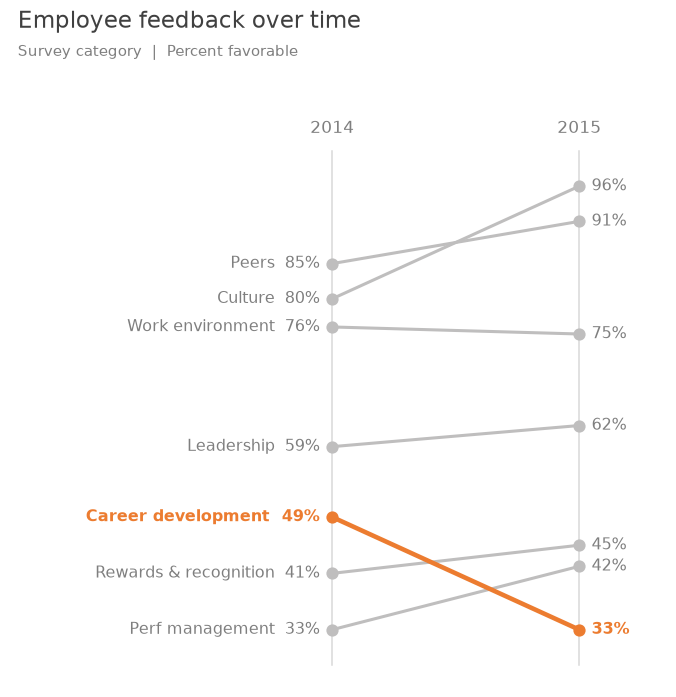

In [31]:
survey = pd.DataFrame({
    "category": ["Peers", "Culture", "Work environment", "Leadership",
                 "Career development", "Rewards & recognition", "Perf management"],
    "2014": [85, 80, 76, 59, 49, 41, 33],
    "2015": [91, 96, 75, 62, 33, 45, 42],
})
HIGHLIGHT = "Career development"
SWD_GRAY, SWD_ORANGE, TEXT_GRAY = "#BFBEBE", "#EC7C30", "#7F7F7F"

fig, ax = plt.subplots(figsize=(6.2, 6.4))
for _, r in survey.iterrows():
    hl = r.category == HIGHLIGHT
    color = SWD_ORANGE if hl else SWD_GRAY
    ax.plot([0, 1], [r["2014"], r["2015"]], color=color, linewidth=3 if hl else 2,
            marker="o", markersize=7, zorder=3 if hl else 2, solid_capstyle="round")
    weight = "bold" if hl else "normal"
    txt = SWD_ORANGE if hl else TEXT_GRAY
    ax.text(-0.05, r["2014"], f"{r.category}  {r['2014']}%", ha="right", va="center",
            color=txt, fontsize=10.5, fontweight=weight)
    ax.text(1.05, r["2015"], f"{r['2015']}%", ha="left", va="center",
            color=txt, fontsize=10.5, fontweight=weight)

# Year headers with a thin rule above each axis, as in the book
for x, year in [(0, "2014"), (1, "2015")]:
    ax.text(x, 103, year, ha="center", va="bottom", color=TEXT_GRAY, fontsize=11)
    ax.plot([x, x], [28, 101], color="#D9D9D9", linewidth=1, zorder=1)

ax.set_xlim(-1.3, 1.35)
ax.set_ylim(25, 110)
ax.axis("off")
fig.text(0.03, 0.965, "Employee feedback over time", fontsize=15, color="#404040", ha="left")
fig.text(0.03, 0.925, "Survey category  |  Percent favorable", fontsize=10, color=TEXT_GRAY, ha="left")
plt.subplots_adjust(top=0.88, left=0.02, right=0.98, bottom=0.03)
plt.savefig("storytelling_slopegraph.png", dpi=150, bbox_inches="tight")
plt.show()

**Why this works:** with seven categories, a clustered bar chart would make you compare 14 bars in pairs. The slopegraph makes the *direction* and *size* of each change visible at once. Most lines go up or stay flat, and the single orange line falling from 49% to 33% jumps out immediately, which is exactly the point the presenter wants the audience to take away.